In [1]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
df = pd.read_csv("Scores.csv", sep=';')
df

,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
0,1,id_001,female,high school,math,23
1,2,id_001,female,high school,language,40
2,3,id_002,female,high school,math,68
3,4,id_002,female,high school,language,"80,5"
4,5,id_003,male,high school,math,82
...,...,...,...,...,...,...
967,968,id_484,female,master's degree,language,"93,5"
968,969,id_485,female,master's degree,math,92
969,970,id_485,female,master's degree,language,100
970,971,id_486,female,master's degree,math,88


In [3]:
df['score'] = df['score'].astype(str).str.replace(',', '.').astype(float)

In [4]:
math_data = df[df['subject'] == 'math']
lang_data = df[df['subject'] == 'language']

In [5]:
m_female = math_data[math_data['gender'] == 'female']['score']
m_male = math_data[math_data['gender'] == 'male']['score']
t_math, p_math = stats.ttest_ind(m_female, m_male, equal_var=False)

In [6]:
l_female = lang_data[lang_data['gender'] == 'female']['score']
l_male = lang_data[lang_data['gender'] == 'male']['score']
t_lang, p_lang = stats.ttest_ind(l_female, l_male, equal_var=False)

In [7]:
print(f"--- Mathematics ---")
print(f"Female Avg: {m_female.mean():.2f}, Male Avg: {m_male.mean():.2f}")
print(f"P-value: {p_math:.5f}")

--- Mathematics ---
Female Avg: 63.86, Male Avg: 68.95
P-value: 0.00018


In [8]:
print(f"\n--- Language ---")
print(f"Female Avg: {l_female.mean():.2f}, Male Avg: {l_male.mean():.2f}")
print(f"P-value: {p_lang:.10f}")


--- Language ---
Female Avg: 73.00, Male Avg: 64.93
P-value: 0.0000000003


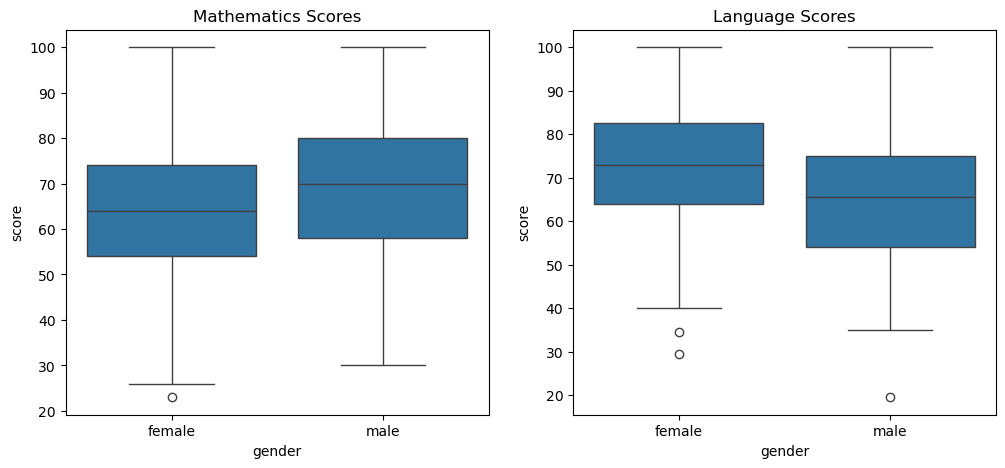

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='gender', y='score', data=math_data)
plt.title('Mathematics Scores')

plt.subplot(1, 2, 2)
sns.boxplot(x='gender', y='score', data=lang_data)
plt.title('Language Scores')
plt.show()

In [10]:
df_pivot = df.pivot(index=['student_id', 'gender', 'parental.level.of.education'], 
                    columns='subject', values='score').reset_index()

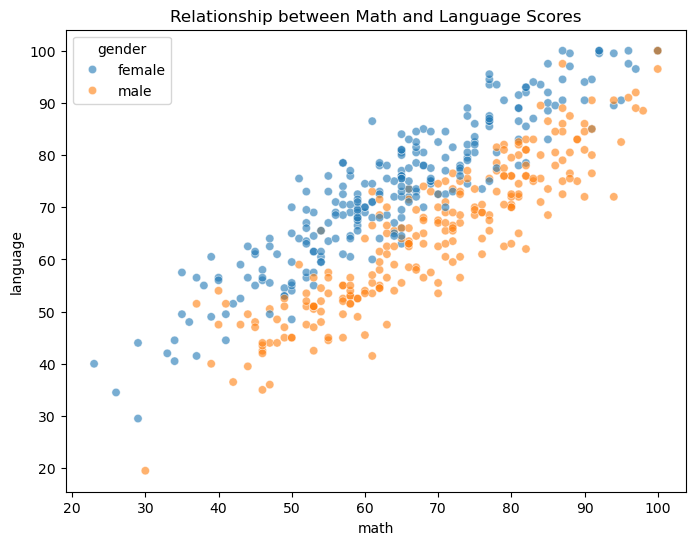

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pivot, x='math', y='language', hue='gender', alpha=0.6)
plt.title('Relationship between Math and Language Scores')
plt.savefig('scatter_math_vs_lang.png')

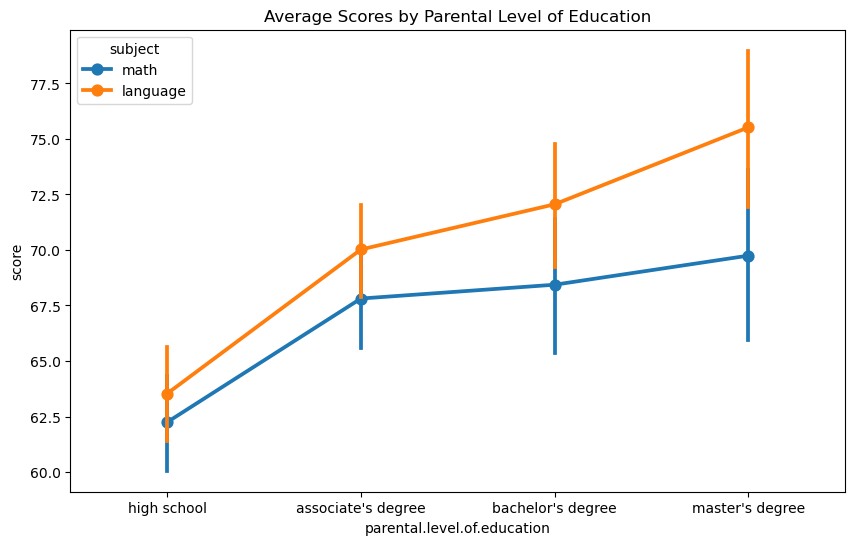

In [12]:
edu_order = ["high school", "associate's degree", "bachelor's degree", "master's degree"]
plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='parental.level.of.education', y='score', hue='subject', order=edu_order)
plt.title('Average Scores by Parental Level of Education')
plt.savefig('parental_edu_trend.png')

In [13]:
math_df = df[df['subject'] == 'math']
f_stat, p_val = stats.f_oneway(*(group['score'] for name, group in math_df.groupby('parental.level.of.education')))
print(f"Math ANOVA P-Value: {p_val}")

Math ANOVA P-Value: 0.0003750888011046905


In [14]:
tukey_math = pairwise_tukeyhsd(endog=math_df['score'], 
                               groups=math_df['parental.level.of.education'], 
                               alpha=0.05)
print(tukey_math)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------


In [15]:
edu_order = ["high school", "associate's degree", "bachelor's degree", "master's degree"]

In [16]:
for subject in ['math', 'language']:
    print(f"\n--- Analysis for {subject.upper()} ---")
    sub_df = df[df['subject'] == subject]
    
    # One-Way ANOVA
    groups = [group['score'].values for name, group in sub_df.groupby('parental.level.of.education')]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"ANOVA Results: F={f_stat:.2f}, p-value={p_val:.5f}")
    
    # Post-hoc Tukey HSD
    if p_val < 0.05:
        tukey = pairwise_tukeyhsd(endog=sub_df['score'], 
                                  groups=sub_df['parental.level.of.education'], 
                                  alpha=0.05)
        print(tukey)


--- Analysis for MATH ---
ANOVA Results: F=6.22, p-value=0.00038
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------

--- Analysis for LANGUAGE ---
ANOVA Results: F=14.24, p-value=0.00000
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1    

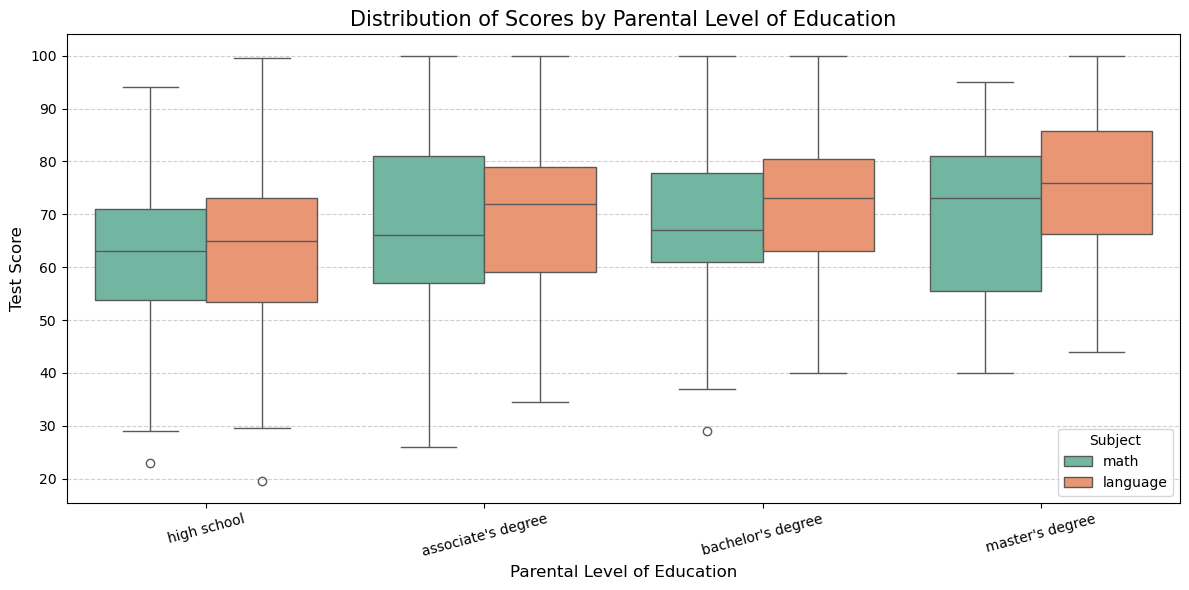

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='parental.level.of.education', y='score', hue='subject', 
            data=df, order=edu_order, palette='Set2')

plt.title('Distribution of Scores by Parental Level of Education', fontsize=15)
plt.xlabel('Parental Level of Education', fontsize=12)
plt.ylabel('Test Score', fontsize=12)
plt.legend(title='Subject')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

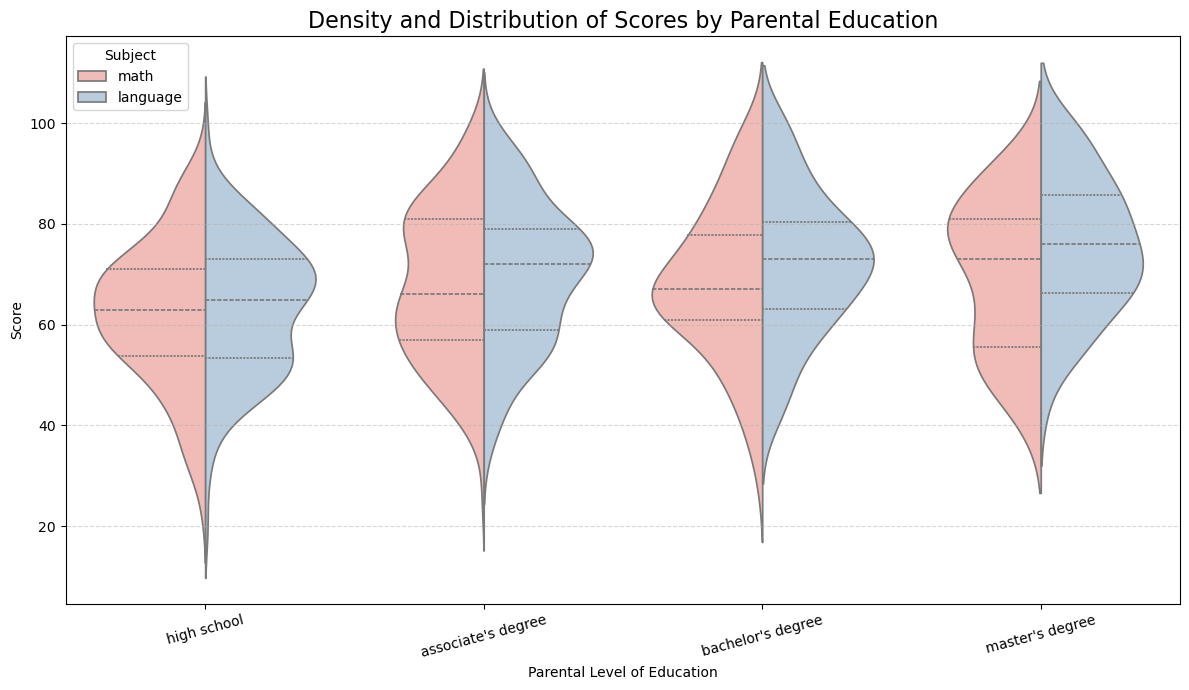

In [18]:
plt.figure(figsize=(12, 7))
# split=True merges the two subjects into one 'violin' for direct comparison
sns.violinplot(x='parental.level.of.education', y='score', hue='subject', 
               data=df, order=edu_order, split=True, inner="quart", palette='Pastel1')

plt.title('Density and Distribution of Scores by Parental Education', fontsize=16)
plt.xlabel('Parental Level of Education')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(title='Subject')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

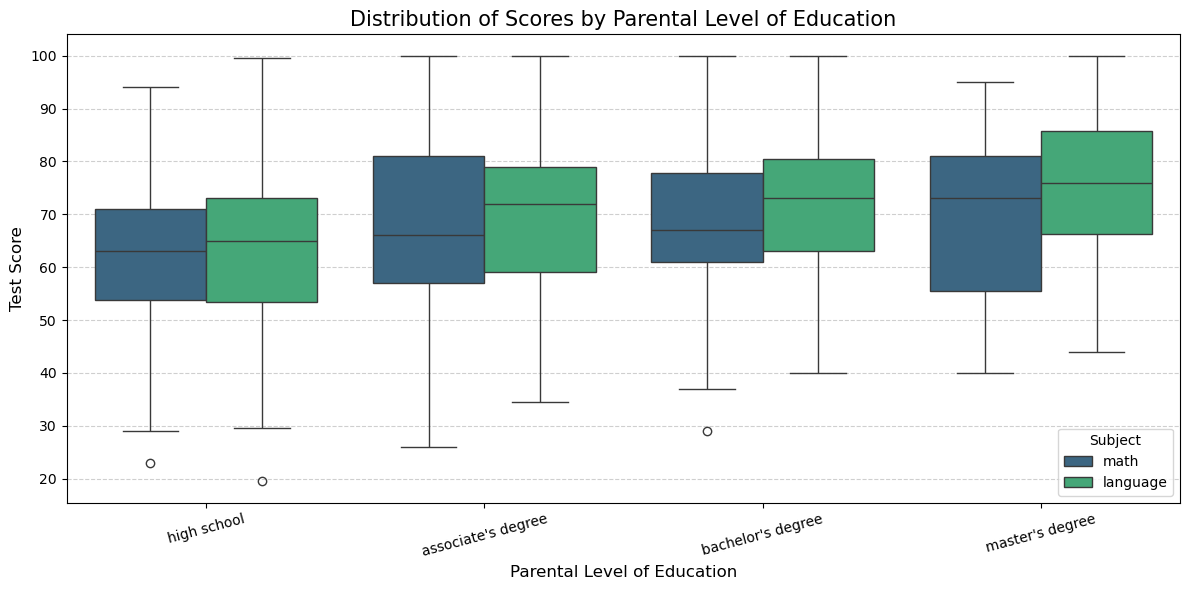

In [19]:
# 3. Create the boxplot with the 'viridis' color palette
plt.figure(figsize=(12, 6))
sns.boxplot(x='parental.level.of.education', y='score', hue='subject', 
            data=df, order=edu_order, palette='viridis')

# 4. Enhance formatting for report quality
plt.title('Distribution of Scores by Parental Level of Education', fontsize=15)
plt.xlabel('Parental Level of Education', fontsize=12)
plt.ylabel('Test Score', fontsize=12)
plt.legend(title='Subject')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# 5. Save the figure for your LaTeX document
plt.savefig('scores_by_education_professional.png')
plt.show()